# Trees, Forests, SVMs & k-NN

<hr style="height: 5px; background-color: cyane ; border: none;">

### Introduction

In Day1 to Day3 notebooks, we explored the fundamentals of supervised learning by building **Linear Regression** and **Logistic Regression** models. In this notebook, we will expand our knowledge by implementing and comparing several other supervised machine learning algorithms, including :
- **Decision Trees**
- **Random Forests**
-  **Support Vector Machines (SVMs)**
-  **K-Nearest Neighbors (KNN)**.

 We will train and evaluate each model on the same dataset, compare their performance using evaluation metrics, and understand how choosing the right algorithm can affect a model's accuracy and overall performance.


<hr style="height: 5px; background-color: cyane ; border: none;">

# Section 1 : Decision Trees

>A decision tree is a supervised learning algorithm used for both classification and regression tasks. It has a hierarchical tree structure which consists of a root node, branches, internal nodes and leaf nodes.
>


## 1.1 How does the model work


It works like a flowchart that helps in making step-by-step decisions, where:

- **Internal nodes** represent attribute tests
- **Branches** represent attribute values
- **Leaf nodes** represent final decisions or predictions.

----

### Step 1: Start with the Root Node

The algorithm begins with the **entire training dataset at the root node**. At this stage, the data usually contains samples from multiple classes, making **the node impure**.

> **Impurity :** is a measure of how mixed the classes are within a node:
> - A node containing samples from only one class has zero impurity (a pure node).
> - A node containing a mixture of different classes has high impurity.
>
Common impurity measures include **Gini Impurity** (the default criterion in scikit-learn) and **Entropy**.

---- 

### Step 2: Search for the Best Split

The algorithm then searches for the best possible way to divide the data.It examines every feature in the dataset and tests multiple possible thresholds for each feature.
For example, if the dataset contains an Age feature, the algorithm may evaluate thresholds such as:

- Age ≤ 20
- Age ≤ 25
- Age ≤ 30
- Age ≤ 35

Similarly, for another feature such as Income, it may test:

- Income ≤ 30,000
- Income ≤ 45,000
- Income ≤ 60,000

These questions are not provided by the programmer. During training, the algorithm automatically generates and evaluates candidate thresholds using the training data.

---- 

### Step 3: Calculate the Information Gain

For every possible split, the algorithm computes the impurity of the resulting child nodes.
It then calculates the Information Gain, which measures how much the impurity decreases after making the split.

Information Gain represents the improvement achieved by splitting the parent node into two children.

The algorithm compares all possible splits and selects the one that produces the highest Information Gain, meaning it creates the greatest reduction in impurity.

---

### Step 5: Stop Growing the Tree

The tree does not necessarily continue until every node has zero impurity.
Training stops when one or more stopping conditions are met, such as:

- A node becomes completely pure (impurity = 0).
- The maximum tree depth has been reached.
- There are too few samples remaining to split.
- No further split significantly improves the model.

**These stopping criteria help prevent the tree from becoming unnecessarily complex and reduce the risk of overfitting.**

----


## 1.2 Building the Model Using Decision Tree

### Step 1 : Starting with loading the dataset, and splittung it into training and testing sets 

In [27]:
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split 


# Load as a dictionary
data = load_breast_cancer()
X, y = data.data, data.target

# split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Step 2 : Fitting the training set into the model

### Parameters the Developer Can Control

The developer does not manually define the questions or thresholds used for splitting. Those are automatically learned from the training data during the ``fit()`` process.

Instead, developers control how the tree is allowed to grow by adjusting its hyperparameters. 

**Some of the most common parameters include:**

```python

DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    criterion="gini"
)
```

- `criterion`: The impurity measure used to evaluate splits (e.g., "gini" or "entropy").
- `max_depth`: Limits the maximum depth of the tree.
- `min_samples_split`: The minimum number of samples required before a node can be split.
- `min_samples_leaf`: The minimum number of samples that each leaf node must contain.
- `max_features`: Limits the number of features considered when searching for the best split.
- `random_state`: Controls the randomness of the algorithm to produce reproducible results.

In [28]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=5,  min_samples_split=10, random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Step 3 : Evaluating the model

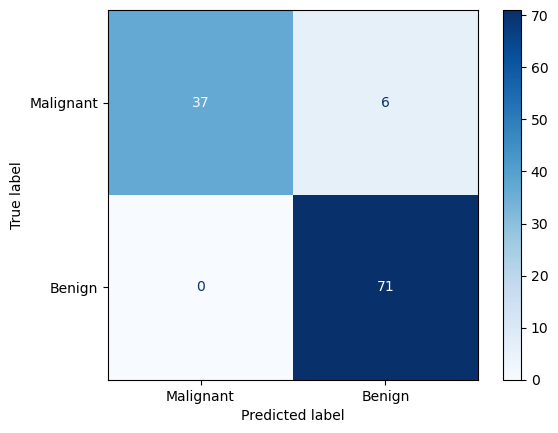

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Malignant", "Benign"],
    cmap="Blues"
)

plt.show()

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



## 1.3 Limitations of Decision Trees



Although Decision Trees are simple to understand and interpret, they have several limitations that should be considered when building machine learning models.

### 1. Overfitting 

The most common problem with Decision Trees is **overfitting**.

If the tree is allowed to grow without restrictions, it may continue creating more branches until it perfectly classifies the training data. Instead of learning general patterns, the tree begins to memorize the training samples, including noise and outliers.

As a result:

- The model achieves very high accuracy on the training set.
- Its performance decreases on new, unseen data because it has learned the training data too specifically.

#### How can we reduce overfitting?

Several techniques can help prevent overfitting:

- Limit the maximum depth of the tree using `max_depth`.
- Increase `min_samples_split` so that nodes are split only when they contain enough samples.
- Increase `min_samples_leaf` to ensure each leaf contains a minimum number of samples.
- Prune the tree by removing branches that contribute little to prediction accuracy.
- Use a **Random Forest**, which combines many Decision Trees and generally produces better generalization.

### 2. Sensitivity to Small Changes

Decision Trees are considered **high-variance models**.

A small change in the training dataset can sometimes produce a significantly different tree structure, leading to different predictions.

**Solution:** Random Forest reduces this instability by averaging the predictions of many different trees.

### 3. Greedy Splitting

Decision Trees build the model using a **greedy algorithm**.

At each node, the algorithm chooses the split that provides the highest immediate Information Gain. It does not look ahead to determine whether a different early split could produce a better overall tree.

Because of this, the final tree is not always the globally optimal one.

### 4. Bias Toward Complex Trees

Without proper constraints, Decision Trees naturally continue growing deeper and creating more branches. Larger trees are more difficult to interpret and are more likely to overfit.

Applying constraints such as `max_depth` or pruning helps produce simpler and more generalizable models.

### Why Random Forest Is Often Preferred

Many of the limitations of a single Decision Tree are addressed by the **Random Forest** algorithm.

Instead of relying on one tree, Random Forest trains many Decision Trees using different subsets of the training data and features. The final prediction is made by combining the predictions of all trees (typically through majority voting for classification or averaging for regression).

This approach usually:

* Reduces overfitting.
* Produces more stable predictions.
* Improves generalization to unseen data.
* Achieves higher predictive accuracy than a single Decision Tree.


<hr style="height: 5px; background-color: cyane ; border: none;">

# Section 2 : Random Forest


A **Random Forest** is a supervised machine learning algorithm used for both **classification** and **regression** tasks. It is an **ensemble learning** method, meaning that instead of relying on a single model, it combines the predictions of many **Decision Trees** to produce a more accurate and reliable result.

The main idea behind Random Forest is known as the **"wisdom of the crowd"**: while a single Decision Tree may make mistakes or overfit the training data, combining the predictions of many trees leads to a model that is more robust and generalizes better to unseen data.



>  <div style="text-align: center;"> <img src="Random_forst.PNG" alt="A descriptive summary of the photo" width="400" > </div>
>
### Key points about Random Forest
1. **Bagging (Bootstrap Aggregating):** This method reduces variance by generating multiple datasets through sampling with replacement.
2. **Random Feature Selection:** During the construction of each decision tree, only a subset of features is considered for splitting at each node, reducing the correlation between trees and improving accuracy.
   
### The result is concluded either by:

1. **Majority Voting:** For classification, where the class with the majority vote is selected.
2. **Averaging:** For regression, where the average prediction from all trees is used.

>  <div style="text-align: center;"> <img src="majority.PNG" alt="A descriptive summary of the photo" width="500" > </div>


## 2.1 How Does the Model Work¶

### Step 1: Create Random Training Subsets (Bootstrap Sampling)

Instead of training every tree on the entire training dataset, Random Forest creates multiple **random subsets** of the training data using a technique called **Bootstrap Sampling**.

Each tree receives a slightly different dataset because the samples are selected **randomly with replacement**, meaning that:

- Some samples may appear multiple times in one subset.
- Some samples may not appear at all.

As a result, every Decision Tree learns slightly different patterns from the data.


-----
### Step 2: Select Random Features

When building each Decision Tree, the algorithm does not consider every feature when searching for the best split. At every node, it randomly selects only a subset of the available features.

For example, suppose a dataset contains ten features.
A single tree might only consider four of them when deciding the next split, while another tree may consider a different set of four features.
This additional randomness makes the trees less similar to one another, which reduces the chance that all trees make the same mistakes.

-----

### Step 3: Train Multiple Decision Trees

Each Decision Tree is trained independently using:

- A different random subset of the training data.
- A different random subset of features at each split.

Each tree grows using the same Decision Tree algorithm:

1. Measure the impurity of the current node.
2. Test candidate thresholds for the selected features.
3. Calculate the Information Gain.
4. Choose the split with the highest Information Gain.
5. Repeat until a stopping condition is reached.

Since every tree is trained on different data and features, the resulting trees are not identical.
 
-----

### Step 4: Combine the Predictions

After all trees have been trained, Random Forest combines their predictions.

#### For Classification

Each tree predicts a class label.

The final prediction is determined using **majority voting**, where the class predicted by the largest number of trees becomes the final prediction.

**Example:**

- Tree 1 → Cat
- Tree 2 → Cat
- Tree 3 → Dog
- Tree 4 → Cat
- Tree 5 → Dog

**Final prediction:** **Cat** (3 out of 5 trees voted for Cat).

#### For Regression

- Each tree predicts a numerical value.
- The Random Forest returns the **average** of all predictions as the final result.

------


## 2.2 Building the Model Using Random Forest

### Step 1 : Starting with loading the dataset, and splittung it into training and testing sets 

In [33]:
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split 


# Load as a dictionary
data = load_breast_cancer()
X, y = data.data, data.target

# split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Step 2 : Fitting the training set into the model

### hyperparameters


Some of the most commonly used parameters include:

- **`n_estimators`**: The number of Decision Trees in the forest. Increasing this value usually improves performance but also increases training time.
- **`criterion`**: The impurity measure used by each Decision Tree (e.g., `"gini"` or `"entropy"`).
- **`max_depth`**: The maximum depth allowed for each tree.
- **`min_samples_split`**: The minimum number of samples required before splitting a node.
- **`min_samples_leaf`**: The minimum number of samples allowed in each leaf node.
- **`max_features`**: The number of randomly selected features considered when searching for the best split.
- **`bootstrap`**: Determines whether bootstrap sampling is used when creating the training subsets.
- **`random_state`**: Ensures reproducible results by controlling the randomness of sampling.

In [7]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(model.feature_importances_) # which features mattered most
predictions = model.predict(X_test)

[0.04870337 0.01359088 0.05326975 0.04755501 0.00728533 0.01394433
 0.06800084 0.10620999 0.00377029 0.00388577 0.02013892 0.00472399
 0.01130301 0.02240696 0.00427091 0.00525322 0.00938583 0.00351326
 0.00401842 0.00532146 0.07798688 0.02174901 0.06711483 0.15389236
 0.01064421 0.02026604 0.0318016  0.14466327 0.01012018 0.00521012]


### Step 3 : Evaluating the model

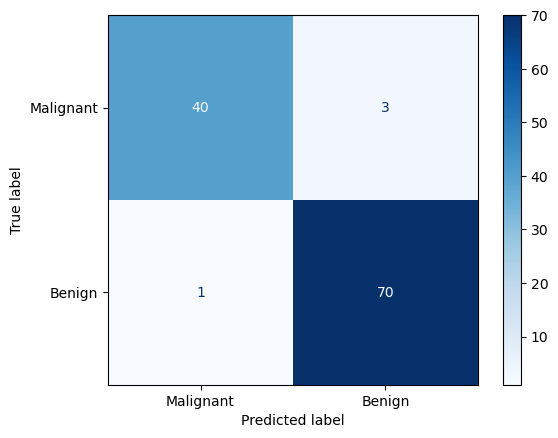

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Malignant", "Benign"],
    cmap="Blues"
)

plt.show()

In [9]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



<hr style="height: 5px; background-color: cyane ; border: none;">

# Section 3 : Support Vector Machines (SVM)

## 3.1 How Does the Model Work



SVR objective is to find the **best possible decision boundary**, called a **hyperplane**, that separates different classes while maximizing the distance between them.

Unlike Decision Trees, which make a sequence of decisions, or Random Forests, which combine many trees, an SVM focuses on finding the **optimal boundary** that best divides the data into different classes.

### Step 1: Plot the Training Data

The algorithm begins by placing every training sample into a feature space.

For example, suppose we have two classes:

- Class A (Blue)
- Class B (Red)

Each sample is represented as a point based on its feature values.

>  <div style="text-align: center;"> <img src="BlueRed.PNG" alt="A descriptive summary of the photo" width="400" > </div>

The goal is to separate these two groups with a boundary.

----
### Step 2: Find Possible Decision Boundaries

In many datasets, there are multiple lines (or hyperplanes) that could separate the classes.

For example, if two classes are already well separated, several different boundaries might correctly classify all training samples.
Instead of choosing any valid boundary, the SVM searches for the **best one**.
>  <div style="text-align: center;"> <img src="Hyperplane.PNG" alt="A descriptive summary of the photo" width="400" > </div>


----

### Step 3: Calculate the Margin

The **margin** is the distance between the separating hyperplane and the nearest training samples from each class.

The main objective of SVM is to **maximize this margin**.

A larger margin generally leads to better generalization because the classifier becomes more robust to small changes or noise in unseen data.

>  <div style="text-align: center;"> <img src="margin.PNG" alt="A descriptive summary of the photo" width="400" > </div>


Rather than simply separating the classes, SVM finds the boundary that leaves the **largest possible gap** between them.

----

### Step 4: Identify the Support Vectors

Not every training sample influences the final decision boundary.

Only the samples closest to the boundary determine its position.

These critical samples are called **Support Vectors**.

They "support" or define the optimal hyperplane.

Interestingly:

- Removing samples far from the boundary usually has little effect on the model.
- Removing one or more support vectors may significantly change the decision boundary.

This is why the algorithm is called a **Support Vector Machine**.

----

### Step 5: Create the Optimal Hyperplane

Once the support vectors have been identified, the algorithm computes the hyperplane that maximizes the margin between the two classes.

For a two-dimensional dataset, this hyperplane is simply a line.

For datasets with more features, the hyperplane becomes a higher-dimensional surface.

The trained model then uses this hyperplane to classify new, unseen samples.

----

### Step 6: Handle Non-Linear Data (Kernel Trick)

Not every dataset can be separated using a straight line.

Some datasets have classes that overlap or form curved patterns.

To solve this problem, SVM uses a technique called the **Kernel Trick**.

A kernel transforms the original data into a higher-dimensional feature space where a linear separator becomes possible.
>  <div style="text-align: center;"> <img src="karnel_trick.PNG" alt="A descriptive summary of the photo" width="400" > </div>


Common kernels include:

- **Linear Kernel** – Used when the data is approximately linearly separable.
- **Polynomial Kernel** – Creates curved decision boundaries.
- **RBF (Radial Basis Function) Kernel** – The most commonly used kernel for complex, non-linear datasets.
- **Sigmoid Kernel** – Behaves similarly to certain neural network activation functions.

The kernel transformation happens internally, so the programmer does not need to manually create additional features.

----

### Why Is SVM Effective?

SVM is a powerful classifier because it focuses on finding the boundary with the **largest margin**, rather than simply separating the classes.

This often leads to:

- Better generalization to unseen data.
- High performance on high-dimensional datasets.
- Strong resistance to overfitting when properly configured.

SVM is particularly effective when:

- The number of features is large.
- The dataset has a clear separation between classes.
- The dataset is relatively small or medium-sized.







## 3.2 Building a SVM Model

### Step 1 : Starting with loading the dataset, and splittung it into training and testing sets 

In [1]:
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split 


# Load as a dictionary
data = load_breast_cancer()
X, y = data.data, data.target

# split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Step 2 : Fitting the training set into the model

#### SVM hyperparameters

- **`kernel`**: Specifies the type of kernel to use (`"linear"`, `"poly"`, `"rbf"`, or `"sigmoid"`).
- **`C`**: Controls the trade-off between maximizing the margin and minimizing classification errors.
  - A **large `C`** tries to classify every training sample correctly but may overfit.
  - A **small `C`** allows some classification errors to achieve a wider margin and better generalization.
- **`gamma`**: Controls how much influence each training sample has when using non-linear kernels such as RBF.
  - A **large `gamma`** creates more complex decision boundaries.
  - A **small `gamma`** creates smoother, simpler boundaries.
- **`degree`**: Specifies the degree of the polynomial when using the Polynomial kernel.
- **`random_state`**: Controls randomness for reproducibility in certain situations.

In [5]:
from sklearn.svm import SVC
model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test) # class probabilities
print(predictions)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]


### Step 3 : Evaluating The Model

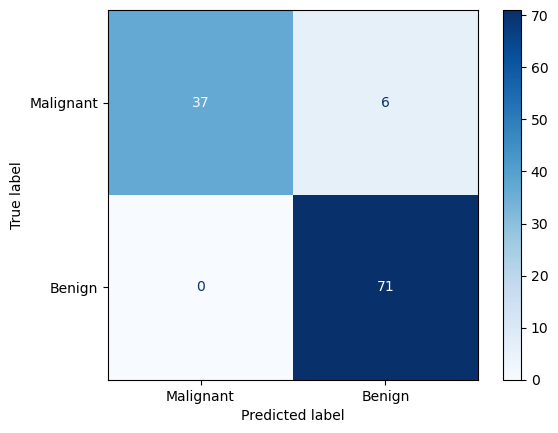

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Malignant", "Benign"],
    cmap="Blues"
)

plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

## 3.3 Limitations of SVM

Although SVM is a powerful algorithm, it has several limitations.

### 1. Computationally Expensive

Training can become slow on very large datasets because the algorithm must optimize the separating hyperplane.

### 2. Sensitive to Parameter Selection

Choosing inappropriate values for `C`, `gamma`, or the kernel can significantly reduce the model's performance.

Hyperparameter tuning is often necessary.

### 3. Requires Feature Scaling

SVM relies on measuring distances between samples.

If one feature has much larger values than another, it can dominate the distance calculations.

Therefore, features are usually standardized using techniques such as **StandardScaler** before training an SVM.

### 4. Less Interpretable

Unlike Decision Trees, which clearly show every decision made, SVM does not produce easily interpretable decision rules.

It is often considered a "black-box" model compared to tree-based algorithms.

<hr style="height: 5px; background-color: cyane ; border: none;">

# Section 4 : k-Nearest Neighbors (k-NN)

## 4.1 How Does the Model Work


k-NN does **not build a mathematical model during training**. Instead, it stores the training data and performs all of its computation when making predictions.
Because of this, k-NN is known as a **lazy learning algorithm** or an **instance-based learning algorithm**.

The main idea behind k-NN is simple:

> **Similar data points tend to belong to the same class.**

To classify a new sample, the algorithm looks at its **k nearest neighbors** in the training dataset and predicts the class that appears most frequently among them.



### Step 1: Store the Training Data

Unlike Decision Trees, Random Forests, and SVMs, k-NN performs almost no learning during training.

When the `fit()` method is called, the algorithm simply stores all the training samples along with their labels.

No decision boundaries or mathematical equations are created at this stage.

This makes training extremely fast.

----

### Step 2: Receive a New Sample

When a new, unseen sample needs to be classified, the algorithm compares it with every sample in the training dataset.

The objective is to determine which training samples are the most similar to the new sample.

----

### Step 3: Calculate the Distance

To measure similarity, k-NN computes the distance between the new sample and every training sample.

The most common distance metric is the **Euclidean Distance**, although other metrics such as Manhattan Distance or Minkowski Distance can also be used.

The smaller the distance, the more similar two samples are considered.

----

### Step 4: Find the k Nearest Neighbors

After calculating all distances, the algorithm sorts the training samples from the closest to the farthest.

It then selects the **k nearest neighbors**.

For example, if:

```python
n_neighbors = 5
```

the algorithm chooses the five closest training samples.

The value of **k** is a hyperparameter chosen by the developer.

---

### Step 5: Make the Prediction

#### For Classification

Each of the **k nearest neighbors** votes for its class.

The class with the majority of votes becomes the final prediction.

**Example:**

Nearest neighbors:

- Neighbor 1 → Cat
- Neighbor 2 → Dog
- Neighbor 3 → Cat
- Neighbor 4 → Cat
- Neighbor 5 → Dog

**Final prediction:** **Cat** (3 out of 5 neighbors voted for Cat).



#### For Regression

Instead of voting, the algorithm computes the **average** of the target values of the nearest neighbors.

This average becomes the predicted numerical value.

----




## 4.2 Building a k-NN Model

### k-NN  hyperparameters



- **`n_neighbors`**: The number of nearest neighbors (k) used for prediction.
- **`weights`**:
  - `"uniform"`: Every neighbor has the same voting weight.
  - `"distance"`: Closer neighbors have more influence than farther neighbors.
- **`metric`**: The distance metric used to measure similarity (e.g., `"euclidean"`, `"manhattan"`, or `"minkowski"`).
- **`algorithm`**: Specifies the search algorithm used to find nearest neighbors (e.g., `"auto"`, `"ball_tree"`, `"kd_tree"`, or `"brute"`).


## 4.3 Limitations of k-NN

Although k-NN is simple and intuitive, it has several limitations.

### 1. Slow Predictions
Because the algorithm compares a new sample with **every training sample**, prediction becomes slower as the dataset grows.
Training is fast, but prediction can be computationally expensive.

### 2. Sensitive to Feature Scaling

Since k-NN relies entirely on distance calculations, features with larger numerical values can dominate the distance computation.
Therefore, features should usually be standardized or normalized before training.

### 3. Suffers from the Curse of Dimensionality

As the number of features increases, the distances between samples become less meaningful.
This phenomenon is known as the **Curse of Dimensionality**, and it often reduces the accuracy of k-NN on high-dimensional datasets.

### 4. Sensitive to Noise and Outliers

When **k** is very small, noisy samples or outliers can strongly influence the prediction.
Choosing a larger value of **k** can help reduce this problem.


<hr style="height: 5px; background-color: cyane ; border: none;">

# Section 5 : Hands-On Lab


###  Model Comparison

> #### In this Section, we will compute all the 4 models explored in the previous sections on the same dataset (Breast cancer from sklearn) and compare which one performe best

### Step 1: Train a decision tree, random forest, SVM, and k-NN on the same train/test split from Day 3.

### Loading the dataset and splitting it

In [10]:
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split 


# Load as a dictionary
data = load_breast_cancer()
X, y = data.data, data.target

# split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


probabilities = model.predict_proba(X_test) # class probabilities

#### Training Decision Tree

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

[[40  3]
 [ 3 68]]


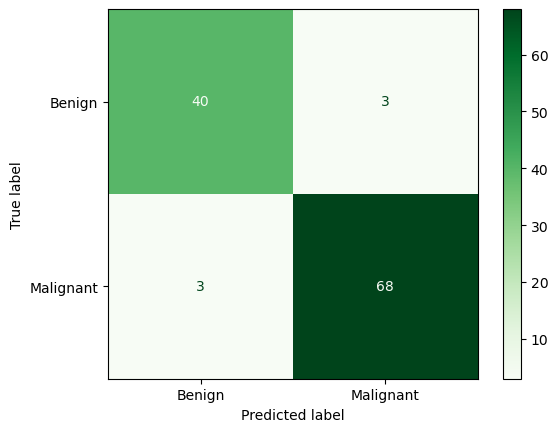

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))


print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Malignant" , "Benign"],  
    cmap="Greens"
)
plt.show()



#### Training Random Forests

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[[40  3]
 [ 1 70]]


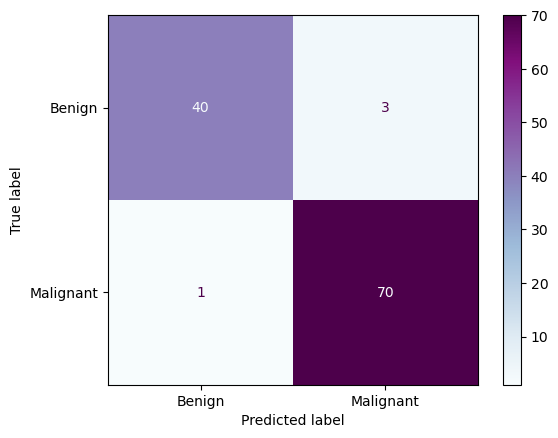

[0.04870337 0.01359088 0.05326975 0.04755501 0.00728533 0.01394433
 0.06800084 0.10620999 0.00377029 0.00388577 0.02013892 0.00472399
 0.01130301 0.02240696 0.00427091 0.00525322 0.00938583 0.00351326
 0.00401842 0.00532146 0.07798688 0.02174901 0.06711483 0.15389236
 0.01064421 0.02026604 0.0318016  0.14466327 0.01012018 0.00521012]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
RF_model.fit(X_train, y_train)
predictions = RF_model.predict(X_test)

print(classification_report(y_test, predictions))


print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Malignant" , "Benign"],  
    cmap="BuPu"
)
plt.show()

print(RF_model.feature_importances_) # which features mattered most



#### Training Support Vector Machines (SVM)

              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

[[37  6]
 [ 0 71]]


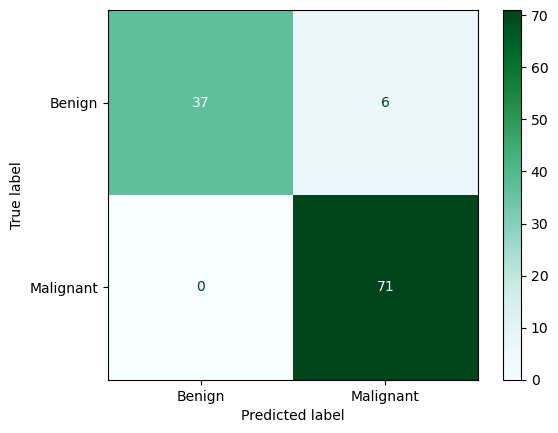

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))


print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Malignant" , "Benign"],  
    cmap="BuGn"
)
plt.show()


#### k-Nearest Neighbors (k-NN)

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

[[38  5]
 [ 0 71]]


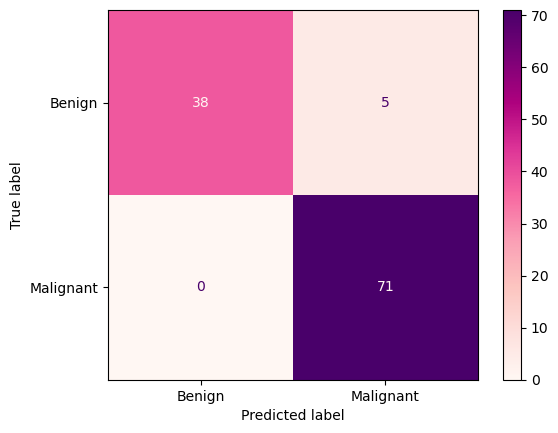

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))


print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Malignant" , "Benign"],  
    cmap="RdPu"
)
plt.show()

### Step 2: Evaluate all four with the same metric (e.g. F1-score) and assemble the results into one comparison table.

#### Model Performance Comparison

(Weighted avg values)
| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Decision Tree | 0.95 | 0.95 | 0.95 |  0.95|
| Random Forest |0.96   | 0.97 |0.96 |0.96 |
| Support Vector Machine (SVM) | 0.95  | 0.95  | 0.95  | 0.95  |
| k-Nearest Neighbors (k-NN) | 0.96 |  0.96|  0.96| 0.96 |

#### Acording to Confusion matrix

#### Decision Tree
- Class 0: 40 samples
- Class 1: 68 samples
- Accurecy :
$$
\frac{108}{114} = 0.947 \approx 94.7\%
$$

#### Random Forest
- Class 0: 40 samples
- Class 1: 70 samples
- Accurecy :

$$
\frac{110}{114} = 0.965 \approx 96.5\%
$$

#### SVM
- Class 0: 37 samples
- Class 1: 71 samples
- Accurecy :
$$
\frac{108}{114} = 0.947 \approx 94.7\%
$$

#### K-NN
- Class 0: 38 samples
- Class 1: 71 samples
- Accurecy
$$
\frac{109}{114} = 0.956 \approx 95.6\%
$$ :

### Step 3: Report the random forest's top feature importances and interpret them.

In [25]:
from sklearn.datasets import load_breast_cancer

print(RF_model.feature_importances_) # which features mattered most

# Load the dataset
data = load_breast_cancer()

# Print all feature names so we can pin point to the index
for i, feature in enumerate(data.feature_names):
    print(i, ":", feature)

[0.04870337 0.01359088 0.05326975 0.04755501 0.00728533 0.01394433
 0.06800084 0.10620999 0.00377029 0.00388577 0.02013892 0.00472399
 0.01130301 0.02240696 0.00427091 0.00525322 0.00938583 0.00351326
 0.00401842 0.00532146 0.07798688 0.02174901 0.06711483 0.15389236
 0.01064421 0.02026604 0.0318016  0.14466327 0.01012018 0.00521012]
0 : mean radius
1 : mean texture
2 : mean perimeter
3 : mean area
4 : mean smoothness
5 : mean compactness
6 : mean concavity
7 : mean concave points
8 : mean symmetry
9 : mean fractal dimension
10 : radius error
11 : texture error
12 : perimeter error
13 : area error
14 : smoothness error
15 : compactness error
16 : concavity error
17 : concave points error
18 : symmetry error
19 : fractal dimension error
20 : worst radius
21 : worst texture
22 : worst perimeter
23 : worst area
24 : worst smoothness
25 : worst compactness
26 : worst concavity
27 : worst concave points
28 : worst symmetry
29 : worst fractal dimension


#### The Strongest feature was the 23ed feature : 0.1538923, which is the worst area column. Meaning this feature contributes 15.4% to the model's decisions.


### Step 4: Identify the best-performing model for this dataset and explain, in Markdown, why it likely won.



**Random Forest model achieved the best overall performance** among the tested algorithms.

It obtained the highest precision score (0.97) and matched the highest accuracy, recall, and F1-score (0.96). Additionally, according to the confusion matrix, Random Forest correctly classified 110 out of 114 test samples, which was the highest number of correct predictions among all models.
The strong performance of Random Forest is likely due to its  nature.  Which combines predictions from multiple trees trained on different subsets of the data and features. This reduces overfitting and improves the model's ability to generalize on the test data.


<hr style="height: 5px; background-color: cyane ; border: none;">

# References

### Decision Trees
- Read more about Decision Tree : https://www.geeksforgeeks.org/machine-learning/decision-tree-introduction-example/
- Summary of Decision Tree algorithm : https://www.youtube.com/watch?v=JcI5E2Ng6r4
### Random Forest
- Summary video : https://www.youtube.com/watch?v=gkXX4h3qYm4
- Read more about Random Forest : https://www.geeksforgeeks.org/r-language/random-forest-approach-in-r-programming/

### Support Vector Machines (SVM)
- Summary video : https://www.youtube.com/watch?v=_YPScrckx28
- Read more about Karnel Trick : https://medium.com/@abhishekjainindore24/svm-kernels-and-its-type-dfc3d5f2dcd8

### K-nearest Neighbors (KNN)
- Summary video of K-NN : https://www.youtube.com/watch?v=gs9E7E0qOIc
